# Probability & Statistics Lab 1: Naive Bayes Classifier

Work breakdown:
-   *Mariia-Daryna Zahariuk* : Data preprocessing, Loading the stop words, Data visualization, Conclusions;
-   *Tymur* : Classifier implementation, Derivation of log-evidence calculation, Prediction implementation;
-   *Kateryna* : Classifier evaluation, Additional task.

## Introduction

During the first three weeks, you learned a couple of essential notions
and theorems, and one of the most important among them is the **Bayes
theorem**:

$$
\mathsf P(A \mid B) = \frac{\mathsf P(A)\mathsf P(B \mid A)}{\mathsf P(B)}.
$$


**Naive Bayes Classifier** is a simple algorithm, which is based on
Bayes theorem and used for solving classification problems.

**Classification problem** is a problem in which an observation has to
be classified in one of the $n$ classes based on its similarity with
observations in each class.

It is a **probabilistic classifier**, which means it predicts based on
the probability of an observation belonging to each class. To compute
it, this algorithm uses **Bayes' formula** as:
$$
\mathsf P (\text{class}_i \mid \text{observation}) = \frac{\mathsf P(\text{class}_i) \mathsf P(\text{observation} \mid \text{class}_i)}{\mathsf P(\text{observation})}. \quad \quad (1)
$$
Breaking down the pieces of the formula,
- $\mathsf P(\text{class}_i)$ is referred to as a **prior** [distribution]: it provides initial class probabilities, influenced by prior beliefs about the problem.
- $\mathsf P(\text{observation} \mid \text{class}_i)$ is the **likelihood**: it tells how likely observations are for a chosen class.
- $\mathsf P(\text{observation})$ is the **evidence**; usually isn't computed directly and used as a normalization constant s.t. sum of $\mathsf P (\text{class}_i \mid \text{observation})$ for all classes is $1$.


This lab focuses on binary classification of text. Text can be considered a sequence of observations/features, with many ways to split it into individual/elementary features. Here, we split the text by words, and one word is considered a feature $\text{feature}_j$:
$\mathsf P(\text{text}) = \mathsf P(\text{features}_1, \text{feature}_2, \dots, \text{feature}_N) = \mathsf P(\text{features}_1)\cdot \mathsf P(\text{feature}_2 \mid \text{feature}_1) \cdot \mathsf P(\text{feature}_3 \mid (\text{feature}_1, \text{feature}_2)) \dots.$

However, modeling such long conditionals is complex, compute-intensive, and requires lots of data.

One way to deal with this is to assume independence, where one can write: $\mathsf P(\text{text}) = \prod_{j=1}^N \mathsf P(\text{feature}_j).$
Or, one could assume the dependence only on the previous word, which will be explored in the additional task!

$\mathsf P(\text{feature}_j)$ is unknown, and we estimate it empirically using the training data split. The empirical probability of some feature $x$ would be $\frac{\text{\# of } x}{\text{total \# of features}}.$
Note that such an approach would turn $\mathsf P(\text{text})$ to $0$ for any completely new feature (as its count among data is zero), which is undesirable.
A common way to deal with this is [Laplace smoothing](https://en.wikipedia.org/wiki/Additive_smoothing). No need to dive deeply into this now, as you will develop a better intuition as you progress through the course.
In this lab, you shall apply Laplace smoothing to both class priors and feature ($\log$–)probabilities.

#### Implementation note

Instead of storing and calculating probabilities directly, many ML solutions prefer computations in $\log$ domain. One of the reasons is numerical stability, which shows up in $\prod_{j=1}^N \mathsf P(\text{feature}_j)$:
each $\mathsf P(\text{feature}_j) \in (0, 1)$ in practice, resulting in tiny final product, which floating-point numbers the computer uses can't store as accurately.
However, in the logarithmic domain even $10^{-100}$ corresponds to an order of magnitude of $-100$.

So, let's rewrite the equation we estimate:
$$
\log [\mathsf P (\text{class}_i \mid \text{observation})] = \underbrace{\log[\mathsf P(\text{class}_i)] + \sum_{j=1}^N \log[\mathsf P(\text{feature}_j)]}_{\text{used to be a numerator, } L_i} - \overbrace{\log[\mathsf P(\text{observation})]}^{\text{used to be a denominator, log-evidence}}. \quad \quad (2)
$$


[A video example of a Naive Bayes](https://www.youtube.com/watch?v=O2L2Uv9pdDA).


### Outline of the work

1.  **Data preprocessing** (1 point) 
2.  **Data visualization** (1 point) 
3.  **Classifier implementation from scratch** (1.5 points)
4.  **Measurements of effectiveness of your classifier** (1.5 points)
5.  **Additional task** (up to 2 points, optional)


*Please submit a pre-executed `.ipynb` notebook for easier evaluation.*


### Data preprocessing

In [11]:
from collections import defaultdict
import math
import pathlib
import re
import pandas as pd
import numpy as np


class Dataset:
    def __init__(self, dataset_dir_path: pathlib.Path):
        self.train_df = pd.read_csv(dataset_dir_path / "train.csv")
        self.test_df = pd.read_csv(dataset_dir_path / "test.csv")

        self.bag_of_words_per_label_id: dict[int, dict[str, int]] = {}
        self.bag_of_log_probabilities_per_label_id: dict[int, dict[str, float]] = {}

    def preprocess_text(self, stop_words: list[str]) -> None:
        """
        Adds "label-id" (starting with 0) and "useful-words" columns to dataframes.
        Useful words are the ones that aren't in the stop words list.
        Remove the punctuation, map all the text to one register (e.g., lowercase).

        You may add custom preprocessing if it's justified!
        """
        stop_set = set(stop_words) if stop_words else set()

        def clean_text(text):
            if not isinstance(text, str):
                return []
            # lowercase the text
            text = text.lower()
            # Remove punctuation and split into words
            words = re.findall(r'\b\w+\b', text)
            # Filter out stop words
            return [w for w in words if w not in stop_set]

        # Automatically determine column names for text and labels
        text_col = 'tweet' if 'tweet' in self.train_df.columns else self.train_df.columns[0]
        label_col = 'label' if 'label' in self.train_df.columns else self.train_df.columns[1]

        # 1. Create 'useful-words' column for train and test
        self.train_df['useful-words'] = self.train_df[text_col].apply(clean_text)
        self.test_df['useful-words'] = self.test_df[text_col].apply(clean_text)

        # 2. Create 'label-id' column (starting with 0)
        unique_labels = sorted(self.train_df[label_col].unique())
        label_to_id = {label: i for i, label in enumerate(unique_labels)}

        self.train_df['label-id'] = self.train_df[label_col].map(label_to_id)
        if label_col in self.test_df.columns:
            self.test_df['label-id'] = self.test_df[label_col].map(label_to_id)


    def calculate_classes_prior(self, smoothing_alpha: float) -> np.ndarray:
        """
        :param smoothing_alpha: parameter of Laplace smoothing.
        :return: distribution of classes after smoothing, starting with label-id 0.
        """
        # Number of unique classes (K) and total number of documents (N)
        num_classes = len(self.train_df['label-id'].unique())
        total_documents = len(self.train_df)

        # Calculate the number of documents for each label-id (from 0 to K-1)
        class_counts = self.train_df['label-id'].value_counts().sort_index().values

        # Laplace smoothing formula for prior probabilities:
        # P(C) = (count(C) + alpha) / (N + alpha * num_classes)
        priors = (class_counts + smoothing_alpha) / (total_documents + smoothing_alpha * num_classes)

        return priors

    def compute_bag_of_words(self) -> None:
        """
        Counts the number of occurrences of each word per label id and updates `self.bag_of_words_per_label_id`.

        Bag of words intro: https://machinelearningmastery.com/gentle-introduction-bag-words-model/.
        Advice: you may use `collections.defaultdict` (https://docs.python.org/3/library/collections.html#collections.defaultdict).
        """
        self.bag_of_words_per_label_id = {}

        # every unique label_id in the training dataset
        for label_id in self.train_df['label-id'].unique():
            word_counts = defaultdict(int)
            # Choose all texts with the current label_id and count the occurrences of each word
            subset = self.train_df[self.train_df['label-id'] == label_id]
            for words in subset['useful-words']:
                for word in words:
                    word_counts[word] += 1
            self.bag_of_words_per_label_id[int(label_id)] = dict(word_counts)


    def compute_bag_of_log_probabilities(self, smoothing_alpha: float) -> float:
        """
        Uses `self.bag_of_words_per_label_id` and updates `self.bag_of_log_probabilities_per_label_id`.
        `self.bag_of_log_probabilities_per_label_id` should store log[P(feature_j)].

        :param smoothing_alpha: parameter of Laplace smoothing.
        :return the log-probability of a new(previously unseen) feature, necessary for evaluation on the test set.
        """
        # Total number of unique words in the training dataset (vocabulary size)
        all_words = set()
        for word_counts in self.bag_of_words_per_label_id.values():
            all_words.update(word_counts.keys())
        vocab_size = len(all_words)

        self.bag_of_log_probabilities_per_label_id = {}
        unseen_log_probs = {}

        for label_id, word_counts in self.bag_of_words_per_label_id.items():
            total_words_in_class = sum(word_counts.values())
            # N_c + alpha * |V|
            denominator = total_words_in_class + smoothing_alpha * vocab_size

            log_probs = {}
            for word, count in word_counts.items():
                p = (count + smoothing_alpha) / denominator
                log_probs[word] = math.log(p)

            self.bag_of_log_probabilities_per_label_id[label_id] = log_probs

            # Log-probability for a new (previously unseen) feature
            unseen_p = smoothing_alpha / denominator
            unseen_log_probs[label_id] = math.log(unseen_p)

        return unseen_log_probs

discrimination_dataset_path = pathlib.Path("discrimination")  # change if needed.
discrimination_dataset = Dataset(discrimination_dataset_path)

labels = discrimination_dataset.train_df["label"].unique().tolist()
print(f"Labels are {labels}.")

Labels are ['discrim', 'neutral'].


Loading the stop words

In [12]:
stop_words_path = pathlib.Path("stop_words.txt")  # change if needed.

stop_words: list[str] = []
with open(stop_words_path) as f:
    for line in f:
        stop_words.append(line.strip())

print(f"Some of the stop words are {stop_words[:8]}.")

Some of the stop words are ['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am'].


In [13]:
discrimination_dataset.preprocess_text(stop_words)

In [14]:
classes_alpha = 1.0
discrimination_dataset.calculate_classes_prior(classes_alpha)

array([0.07030482, 0.92969518])

In [15]:
discrimination_dataset.compute_bag_of_words()

In [16]:
features_alpha = 1.0
unseen_feature_log_prob = discrimination_dataset.compute_bag_of_log_probabilities(features_alpha)

### Data visualization

Visualize the dataset, its properties, etc. You may use external libraries such as `matplotlib`, `plotly`, etc. Data analysis could provide hints/ideas for downstream classifier evaluation.

/tmp/ipykernel_15773/202912052.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_15773/202912052.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_15773/202912052.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_words, x="count", y="word", ax=axes[2], palette="mako")


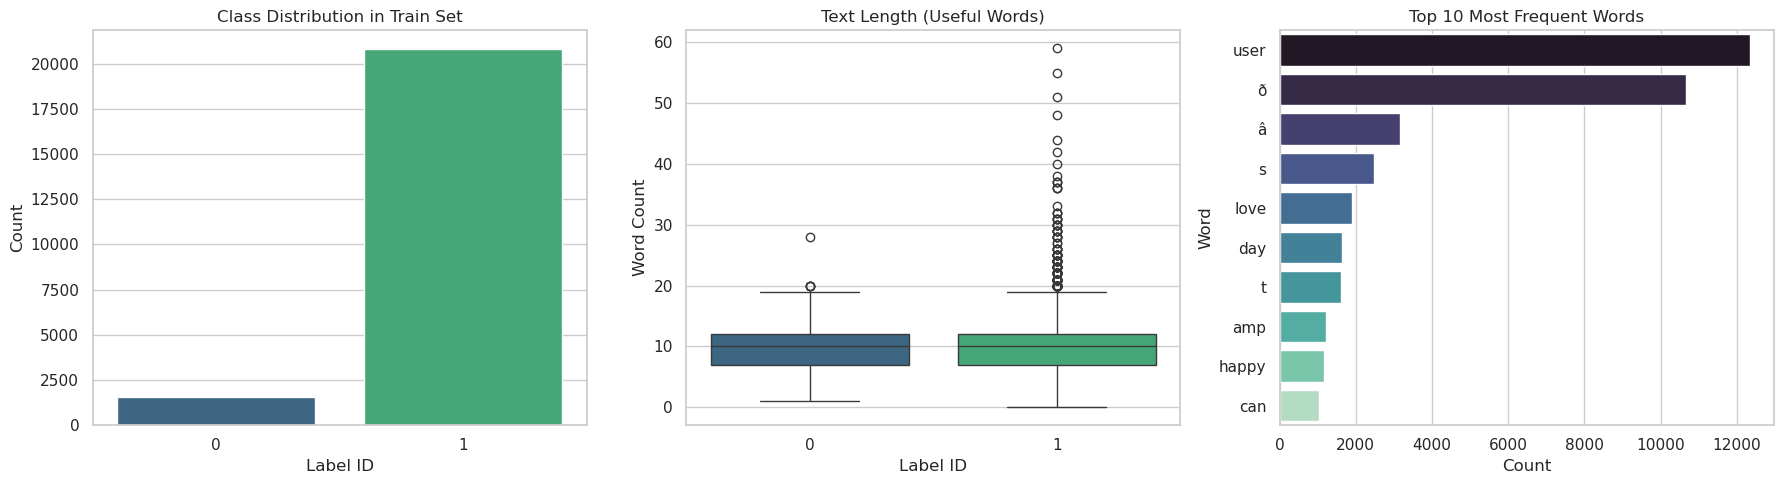

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution
sns.countplot(
    data=discrimination_dataset.train_df,
    x="label-id",
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Class Distribution in Train Set")
axes[0].set_xlabel("Label ID")
axes[0].set_ylabel("Count")

# 2. Text Length Distribution
train_df_copy = discrimination_dataset.train_df.copy()
train_df_copy["text_len"] = train_df_copy["useful-words"].apply(len)

sns.boxplot(
    data=train_df_copy,
    x="label-id",
    y="text_len",
    ax=axes[1],
    palette="viridis",
)
axes[1].set_title("Text Length (Useful Words)")
axes[1].set_xlabel("Label ID")
axes[1].set_ylabel("Word Count")

# 3. 10 most frequent words in the training dataset
all_words = [
    word for words in train_df_copy["useful-words"] for word in words
]
top10_words = pd.DataFrame(
    Counter(all_words).most_common(10), columns=["word", "count"]
)

sns.barplot(data=top10_words, x="count", y="word", ax=axes[2], palette="mako")
axes[2].set_title("Top 10 Most Frequent Words")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Word")

plt.tight_layout()
plt.show()

In [10]:
print("Колонки train_df:", discrimination_dataset.train_df.columns)
print(discrimination_dataset.train_df.head(2))

Колонки train_df: Index(['label', 'tweet', 'useful-words', 'label-id'], dtype='str')
     label                                              tweet useful-words  \
0  discrim  #allahsoil the term jihad is a highly-conteste...    [discrim]   
1  neutral  @user @user and so called "moderate muslims" j...    [neutral]   

   label-id  
0         0  
1         1  


### Classifier implementation

Recall equation $(2)$. You will manually calculate the *"used to be a numerator"* part, call it $L_i$, for each class, while log-evidence is numerically safely calculated from an array of log-domain per-class numerators.


In [ ]:
def compute_log_evidence(per_label_log_domain_numerator: np.ndarray) -> float:
    return np.logaddexp.reduce(per_label_log_domain_numerator)

#### Derivation of log-evidence calculation

Assume all $L_i$ are calculated. Derive how one would calculate log-evidence. Later explain how it connects to the provided above `compute_log_evidence` function.

Hint: use the property of valid probability distributions.

$$
\text{[a block for your formulas.]}
$$

#### Prediction implementation

In [ ]:
from typing import Literal


def predict(dataset: Dataset, split: Literal["train", "test"]) -> np.ndarray:
    """
    "train" split option may be useful for debugging.
    :return: the (NxC) array of predicted probabilities, where N is the number of texts, and C is the number of classes.
    """
    predicted_probabilities = []
    # NOTE: implement.
    ...

    return np.array(predicted_probabilities)

### Classifier evaluation

Note that accuracy is not always a good metric for the classifier. One may look at precision and recall curves, F1 score metric, ROC curves.

When evaluating the model, it's important to understand the
different types of classification results:

-   A ***true positive***(TP) result is one where the model correctly
    predicts the positive class.
-   A ***true negative***(TN) result is one where the model correctly
    predicts the negative class.
-   A ***false positive***(FP) result is one where the model incorrectly
    predicts the positive class when it is actually negative.
-   A ***false negative***(FN) result is one where the model incorrectly
    predicts the negative class when it is actually positive.

Precision measures the proportion of true positive predictions among all positive predictions made by the model: $\text{Precision} = \frac{TP}{TP+FP}.$

Recall measures the proportion of true positives identified out of all actual positive cases: $\text{Recall} = \frac{TP}{TP+FN}$.


F1 score is the harmonic mean of both precision and recall: $\text{F1} = \frac{2\times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}.$

See [this link](https://cohere.com/blog/classification-eval-metrics) to find more information about metrics.

Visualize plots and show failure cases.

### Additional task

You are asked to explore, implement, evaluate, and analyze another way to calculate $\mathsf P(\text{text})$; mainly, by conditioning on the previous feature:
$$
\mathsf P(\text{text}) = \prod_{j=2}^N \mathsf P(\text{feature}_j \mid \text{feature}_{j-1}).
$$

The task will be graded proportionally to analysis depth and conclusions viability.

### Conclusions

Summarize your work by explaining in a few sentences the points listed
below.

- Describe the method implemented in general. Show what are
    mathematical foundations you are basing your solution on.
- List pros and cons of the method. This should include the
    limitations of your method, all the assumption you make about the
    nature of your data etc.
- Explain why accuracy is not a good choice for the base metrics for
    classification tasks. Why is F1 score generally preferable?


- **Method & Mathematical Foundations:** We implemented a Multinomial Naive Bayes classifier for text classification. The approach is built on Bayes' Theorem with the naive assumption of conditional independence among words given the class. To prevent numerical underflow, calculations are performed in the log-domain. Laplace smoothing ($\alpha = 1.0$) is applied to avoid zero probabilities for previously unseen words.

- **Pros & Cons / Assumptions:**
  - *Pros:* Fast training and inference, low computational cost, highly effective for small or sparse text datasets.
  - *Cons / Limitations:* The core assumption that word occurrences are completely independent given the class does not hold in real natural language, ignoring word context and grammar order.

- **Why Accuracy is Not Enough & F1 Score is Preferred:** Accuracy can be misleading under class imbalance because a dummy model predicting only the majority class can easily achieve high accuracy. F1 score, being the harmonic mean of Precision and Recall, provides a much more robust evaluation by measuring performance on both positive and negative classes fairly.